##### Application of Levenberg-Marquardt via Chapman-Richards algorithm
* $$y(t) = \alpha(1 - \beta e^{-kt})^\frac{1}{1- m}$$
Where: 
* $y(t)$ is the size at time $t$ (i.e Tree Height)
* $\alpha$ is the upper asymptote (i.e Max size)
* $\beta$ is the scaling parameter (i.e related to initial size)
* $m$ is the shape parameter (i.e controls curve shape)
* $k$ is the growth rate
---
Intuitively it represents forest growth
* Slow Growth (i.e the trees are young)
* Rapid Growth (i.e optimal conditions)
* Plateau (i.e reaching maximum size)
---
* Goal is to find optimal parameters for $\alpha, \beta, k, m$
---
The Jacbian form of Chapman-Richards is:
\begin{equation}
J =\begin{bmatrix}\frac{\partial}{\partial \alpha} & \frac{\partial}{\partial \beta} & \frac{\partial}{\partial k} & \frac{\partial}{\partial m}
\end{bmatrix}
\end{equation}



\begin{equation}
J =\begin{bmatrix} (1 - \beta e^{-kt})^\frac{1}{1- m}, & \alpha \frac{1}{1 - m}(1 - \beta e^{-kt})^{\frac{m}{1 - m}}(-e^{-kt}), & \alpha \frac{1}{1 - m}(1 - \beta e^{-kt})^{\frac{m}{1- m}}(\beta te^{-kt}), & \frac{\alpha \ln(1 - \beta e^{-kt})(1 - \beta e^{-kt})^\frac{1}{1 - m}}{(1 - m)^2}
\end{bmatrix}
\end{equation}
---

##### The residuals in general is:
$r_i(\theta) = y_i - f(t_i, \theta)$
* $y_i$ is the observed data
* $f(t_i, \theta)$ is the model prediction
* $r_i$ is the error at point $i$
##### Therefore, for Chapman-Richard the residual models is:
* $r_i(\alpha, \beta, k, m) = y_i - \alpha(1 - \beta e^{-kt_i})^\frac{1}{1 - m}$
* So, the non- linear square minimizers $\lvert r(\theta) \rVert^2$ = $\sum_{i} r_i^2$

---

Let the trust region reduction method be:
* $ared = f(x)- f(x + \delta)$
* $pred = -(g^T \delta + \frac{1}{2} \delta ^T (J^T J)\delta )$
* Where $g = J^T r$
* So, $p = \frac{ared}{pred}$

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 


In [2]:
# Synthetic data
# We generate synthetic data using the Chapman-Richardson model
#  with known parameters and add some noise to simulate real-world measurements.
t = np.array([1,2,3,4,5,6,7,8], dtype=float)
theta = np.array([15.0, 0.3, 0.3, 0.6]) # [alpha, beta, k, m]
iterations = 20
lam = 1.0
history = []
y_true = (20 *(1 - 0.5* np.exp(-0.4 * t))**(1/ (1 - 0.5)))
noise = np.random.normal(0, 0.5, size=len(t))
y = y_true + noise

# Store Results
all_theta = []
all_curvatures = []

# ----------------------
# Model function
# ----------------------

def Chapman_Richardson(alpha, b, k, m, t):

    base = 1 - b * np.exp(-k * t)
    base = np.clip(base, 1e-8, None)

    return alpha * base**(1 / (1 - m))

# ----------------------
# Residuals
# ----------------------

def res(theta):
    alpha, b, k, m = theta
    return (y) - Chapman_Richardson(alpha, b, k, m, t)

# ----------------------
# Jacobian
# ----------------------

def Jacobian(theta):
    alpha, b, k, m = theta

    exp_term = np.exp(-k * t)
    base = 1 - b * exp_term
    base = np.clip(base, 1e-8, None)
    c = 1 / (1 - m)
    d = m / (1 - m)
    J = np.zeros((len(t), 4))

    # ∂/∂alpha
    J[:, 0] = base**c

    # ∂/∂b
    J[:, 1] = alpha * c * base**(d) * (-exp_term)# * dbeta

    # ∂/∂k
    J[:, 2] = alpha * c * base**(d) * (b * t * exp_term) #* dk

    # ∂/∂m
    J[:, 3] = (alpha * np.log(base) * base**(d)) / (1 - m)**2
    return -J

for trial in range(4):
    theta = np.array([
    np.random.uniform(10, 25),   # alpha
    np.random.uniform(0.1, 0.9), # b
    np.random.uniform(0.1, 1.0), # k
    np.random.uniform(0.1, 0.9)  # m
    ])

    lam = 1.0
        
    for _ in range(20):
        r = res(theta)
        J = Jacobian(theta)

        JTJ = J.T @ J # curvature 
        JTr = J.T @ r # direction
        A = JTJ + lam * np.eye(4)
        g = J.T @ r
        delta = np.linalg.solve(A, -JTr)

        theta_new = theta + delta

        # Ensure parameters are in valid ranges

        alpha, b, k, m = theta_new
        b = np.clip(b, 0.001, 0.999) # Ensure b is in (0, 1)
        k = np.clip(k, 1e-9, None) # Ensure k is positive
        m = np.clip(m, 0.001, 0.999) # Ensure m is in (0, 1)

        # Compute actual reduction in error

        err = np.sum(r**2)
        err_new = np.sum(res(theta_new)**2)
        ared = err - err_new
        history.append(theta.copy())

        # Predicted reduction in error

        pred = -(g @ delta + 0.5 * delta @ (JTJ @ delta))

        # Compute rho

        if pred <= 0:
            rho = 0
        else:
            rho = ared / pred

        print(f"iter {_}: theta={theta}, err={err:.4f}, p={rho:.4f}, λ={lam:.4f}")

        # Update parameters

        if rho > 0:
            theta = theta_new

        if rho > 0.75:
            lam *= 0.5
        elif rho < 0.25:
            lam *= 2.0

    all_theta.append(theta)
    all_curvatures.append(Chapman_Richardson(*theta, t))

for i, theta in enumerate(all_theta):
    alpha, b, k, m = theta
    print(f"Run {i}: alpha={alpha:.4f}, b={b:.4f}, k={k:.4f}, m={m:.4f}")

iter 0: theta=[20.69978563  0.16284279  0.42810231  0.57144812], err=102.7855, p=1.4953, λ=1.0000
iter 1: theta=[20.58411558  0.35274913  0.2576672   0.63339572], err=26.5776, p=1.6891, λ=0.5000
iter 2: theta=[20.30662231  0.17018804  0.34685881  0.79172843], err=4.9270, p=1.8013, λ=0.2500
iter 3: theta=[20.15926235  0.24887151  0.43843087  0.76335927], err=1.1875, p=-1.9683, λ=0.1250
iter 4: theta=[20.15926235  0.24887151  0.43843087  0.76335927], err=1.1875, p=0.5190, λ=0.2500
iter 5: theta=[20.18383131  0.40848704  0.4438321   0.63576345], err=1.0760, p=-11.0919, λ=0.2500
iter 6: theta=[20.18383131  0.40848704  0.4438321   0.63576345], err=1.0760, p=-4.0830, λ=0.5000
iter 7: theta=[20.18383131  0.40848704  0.4438321   0.63576345], err=1.0760, p=-0.7505, λ=1.0000
iter 8: theta=[20.18383131  0.40848704  0.4438321   0.63576345], err=1.0760, p=0.7181, λ=2.0000
iter 9: theta=[20.20873688  0.43517168  0.42519931  0.59266071], err=0.9737, p=0.4122, λ=2.0000
iter 10: theta=[20.23371368  0.4

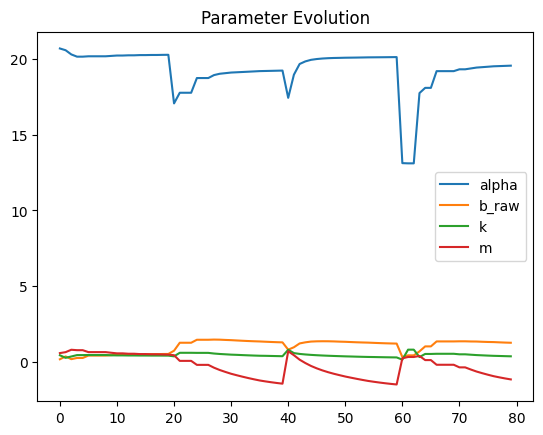

In [3]:
history = np.array(history)

plt.plot(history[:,0], label="alpha")
plt.plot(history[:,1], label="b_raw")
plt.plot(history[:,2], label="k")
plt.plot(history[:,3], label="m")
plt.legend()
plt.title("Parameter Evolution")
plt.show()

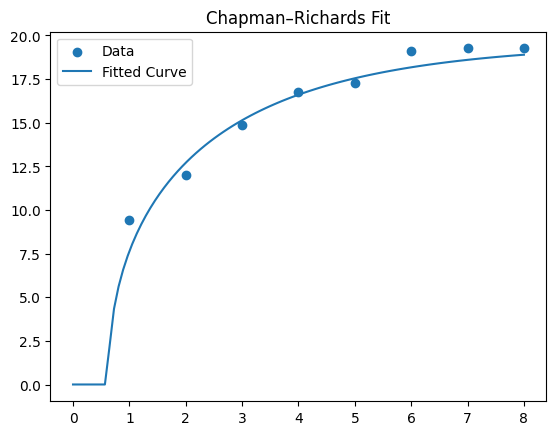

In [4]:
t_dense = np.linspace(0, 8, 100)

def model_dense(theta):
    alpha, b, k, m = theta

    base = 1 - b * np.exp(-k * t_dense)
    base = np.clip(base, 1e-8, None)

    return alpha * base**(1 / (1 - m))

plt.scatter(t, y, label="Data")
plt.plot(t_dense, model_dense(theta), label="Fitted Curve")
plt.legend()
plt.title("Chapman–Richards Fit")
plt.show()

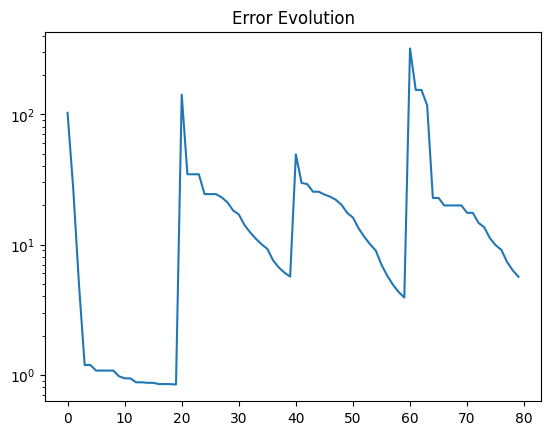

In [9]:
errors = [np.sum(res(theta_i)**2) for theta_i in history]
plt.title("Error Evolution")
plt.plot(errors)
plt.yscale('log')

Text(0.5, 1.0, 'Model Curves for Varying Shape Parameter m')

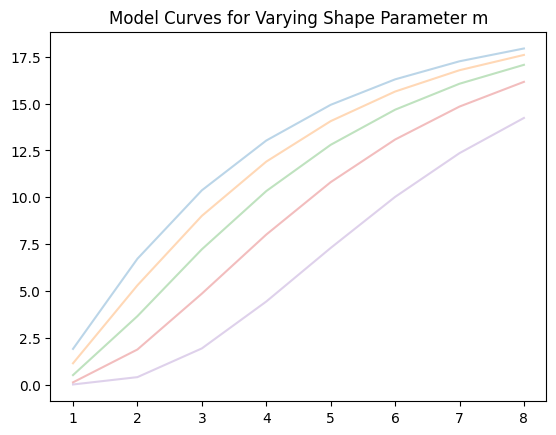

In [12]:
m_vals = np.linspace(0.1, 0.9, 50)

for m in m_vals[::10]:
    y_curve = Chapman_Richardson(alpha, b, k, m, t)
    plt.plot(t, y_curve, alpha=0.3)

plt.title("Model Curves for Varying Shape Parameter m")

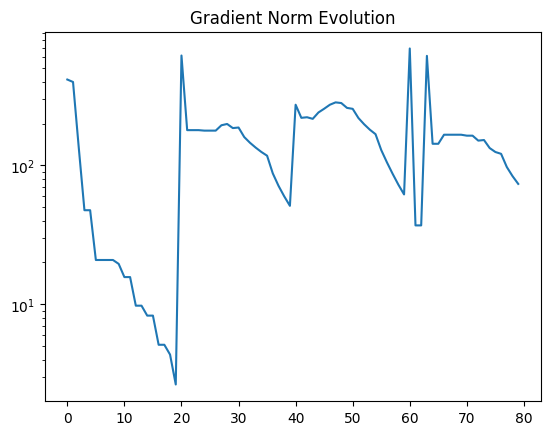

In [13]:
grad_norms = [np.linalg.norm(Jacobian(th).T @ res(th)) for th in history]
plt.plot(grad_norms)
plt.title("Gradient Norm Evolution")
plt.yscale('log')

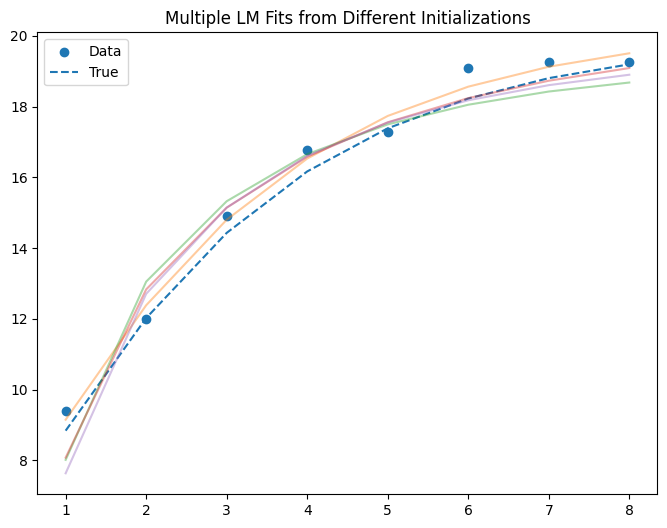

In [8]:
t_fine = np.linspace(min(t), max(t), 100)

plt.figure(figsize=(8,6))

# noisy data
plt.scatter(t, y, label="Data")

# true curve
plt.plot(t, y_true, linestyle='--', label="True")

# fitted curves
for curve in all_curvatures:
    plt.plot(t, curve, alpha=0.4)

plt.title("Multiple LM Fits from Different Initializations")
plt.legend()
plt.show()